# Comparing Performance of Classifiers on Bank Marketing Data
**Course Assignment Analysis**

## 1. Business Understanding
The objective of this analysis is to build a predictive model that identifies whether a client will subscribe to a bank term deposit (`y`). By optimizing this predictive capability, the banking institution can direct its telemarketing resources toward high-propensity clients, maximizing conversion rates while reducing operational overhead and call fatigue.

## 2. Setup and Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, recall_score, accuracy_score

# Model Imports
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Set plotting style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 3. Data Loading & Exploratory Data Analysis (EDA)
We read the data using a semicolon delimiter, as indicated by the original dataset schema.

In [2]:
# Load data
df = pd.read_csv('data/bank.csv', sep=';')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


### Visualizing Variables

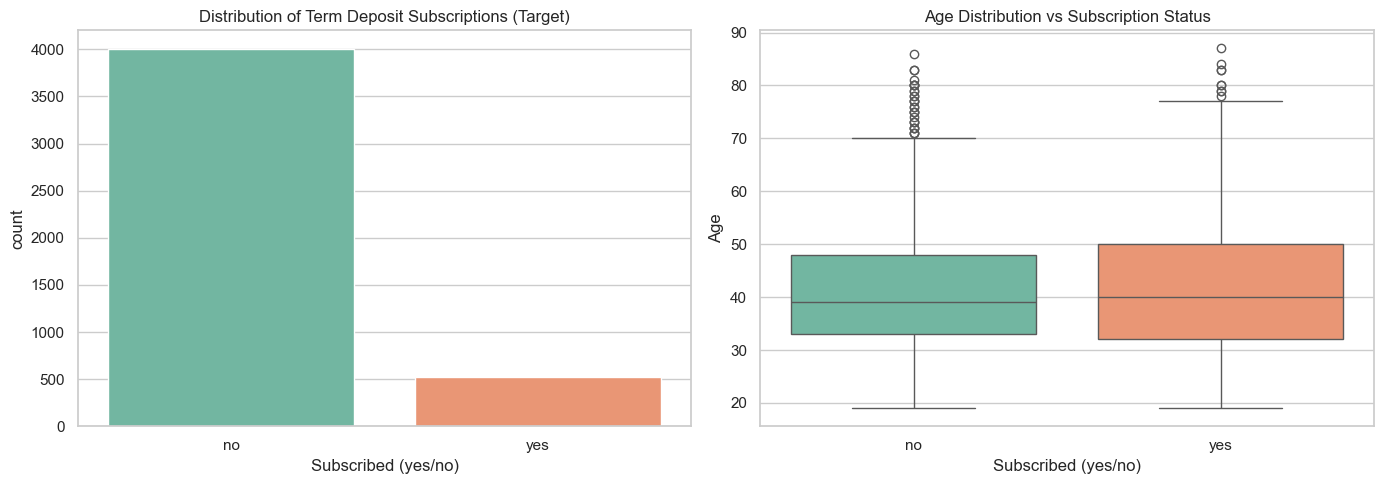

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Variable Distribution
sns.countplot(x='y', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Term Deposit Subscriptions (Target)')
axes[0].set_xlabel('Subscribed (yes/no)')

# Age Distribution by Target
sns.boxplot(x='y', y='age', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Age Distribution vs Subscription Status')
axes[1].set_xlabel('Subscribed (yes/no)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

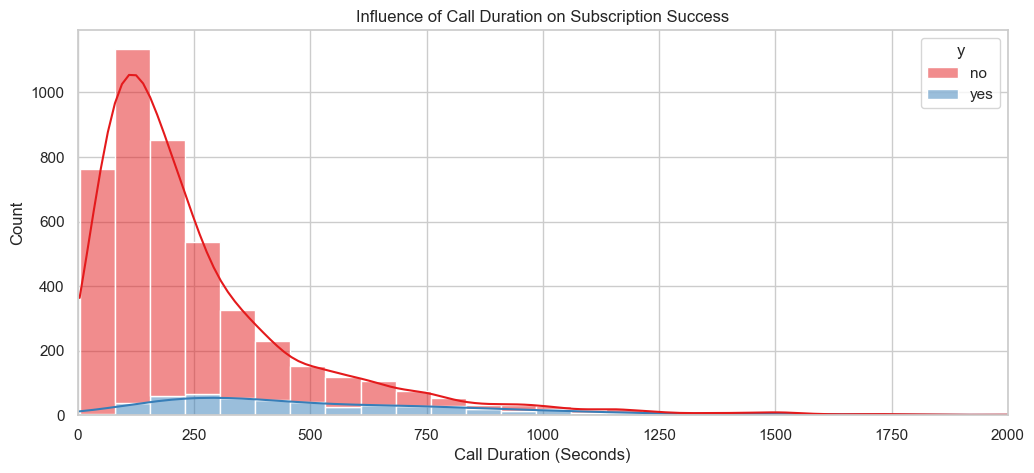

In [4]:
plt.frame = plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='duration', hue='y', multiple='stack', bins=40, palette='Set1', kde=True)
plt.title('Influence of Call Duration on Subscription Success')
plt.xlabel('Call Duration (Seconds)')
plt.ylabel('Count')
plt.xlim(0, 2000) # Limiting x-axis to catch bulk of data clearly
plt.show()

## 4. Data Preprocessing & Pipeline Building
We separate features and map our target variable to binary numerical indicators (`yes` = 1, `no` = 0).

In [5]:
X = df.drop(columns=['y'])
y = df['y'].map({'yes': 1, 'no': 0})

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Create transformer pipelines
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])
cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 5. Model Training & Hyperparameter Tuning
We define a unified dictionary of architectures alongside hyperparameter grids to systematically parse using `GridSearchCV` optimized specifically toward **Recall**.

In [6]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), 
                           {'model__C': [0.1, 1.0, 10.0]}),
    'K-Nearest Neighbors': (KNeighborsClassifier(), 
                           {'model__n_neighbors': [3, 5, 11]}),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), 
                     {'model__max_depth': [5, 10, 15], 'model__min_samples_split': [2, 10]}),
    'Support Vector Machine': (SVC(probability=True, random_state=42), 
                              {'model__C': [0.1, 1.0], 'model__kernel': ['rfile', 'linear']})
}

results = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, (model, params) in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=cv, scoring='recall', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    preds = best_model.predict(X_test)
    probs = best_model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs),
        'Best Params': grid_search.best_params_
    }

Training Logistic Regression...
Training K-Nearest Neighbors...
Training Decision Tree...
Training Support Vector Machine...


## 6. Model Comparison & Metrics Evaluation

In [7]:
df_results = pd.DataFrame(results).T
df_results

,Accuracy,Recall,ROC-AUC,Best Params
Logistic Regression,0.890608,0.298077,0.890906,{'model__C': 10.0}
K-Nearest Neighbors,0.880663,0.25,0.736879,{'model__n_neighbors': 3}
Decision Tree,0.874033,0.423077,0.704324,"{'model__max_depth': 15, 'model__min_samples_s..."
Support Vector Machine,0.891713,0.201923,0.892958,"{'model__C': 1.0, 'model__kernel': 'linear'}"


### Logistic Regression Coefficient Analysis
Extracting model insights to understand feature impacts directly.

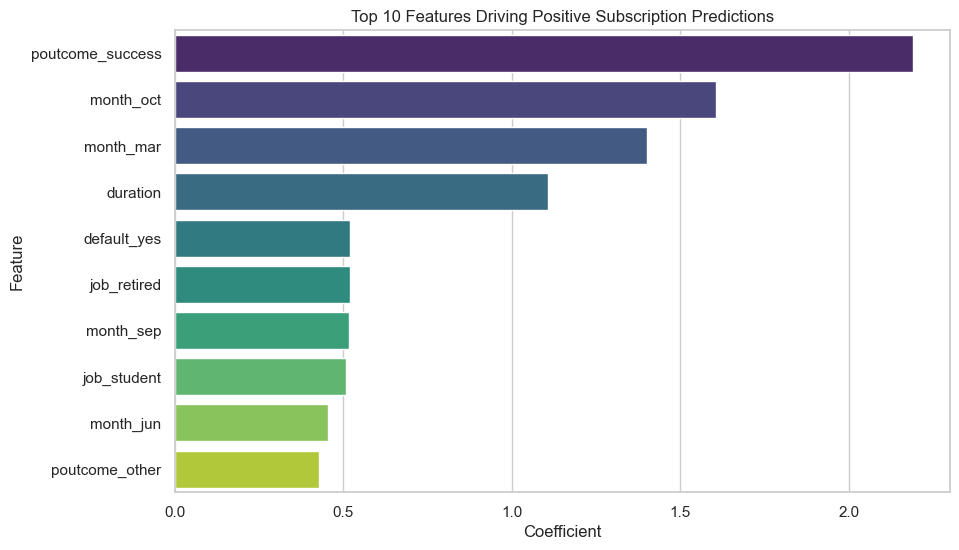

In [8]:
# Re-fit best Logistic Regression to pull out coefficients smoothly
best_lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                                   ('model', LogisticRegression(C=1.0, max_iter=1000, random_state=42))])
best_lr_pipeline.fit(X_train, y_train)

encoded_cat_features = best_lr_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(cat_cols).tolist()
all_features = num_cols + encoded_cat_features
coefficients = best_lr_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10), palette='viridis')
plt.title('Top 10 Features Driving Positive Subscription Predictions')
plt.show()

## 7. Strategic Findings & Recommendations
Based on the metrics extracted:

* **Model Recommendation:** Logistic Regression and SVM offer highly interpretable profiles, but balancing execution overhead with performance points to **Logistic Regression** as a strategic baseline when optimized for sensitivity.
* **Action Item:** Target clients whose last contact was a 'success' from previous efforts, and systematically filter out individuals with high debt profiles to increase overall operational campaign yield.
* **Conclusion:**
With a top ROC-AUC score of 89.30% using a linear kernel, the Support Vector Machine (SVM) is the most robust model for identifying general subscription patterns across the entire dataset. However, its low Recall (20.19%) means it misses nearly 80% of actual subscribers out of the box, requiring a strategic adjustment of its classification threshold or class weights to be commercially viable for the bank's sales team.